# Phase 1 — Data Preparation & Feature Extraction

In [2]:

# Imports
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    precision_recall_fscore_support
)

np.random.seed(42)
print("Libraries imported successfully.")


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Libraries imported successfully.


In [3]:

# Load dataset
BASE_PATH = '/kaggle/input/railway-track-fault-detection/Railway Track fault Detection Updated'

def load_image_paths_and_labels(base_dir):
    image_paths, labels = [], []
    class_map = {'Non defective': 0, 'Defective': 1}
    for label_name in os.listdir(base_dir):
        class_dir = os.path.join(base_dir, label_name)
        if not os.path.isdir(class_dir):
            continue
        label_idx = class_map.get(label_name)
        if label_idx is None:
            continue
        for fname in os.listdir(class_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(class_dir, fname))
                labels.append(label_idx)
    return image_paths, np.array(labels), class_map


In [4]:

X_train_paths, y_train, class_map = load_image_paths_and_labels(f"{BASE_PATH}/Train")
X_val_paths, y_val, _ = load_image_paths_and_labels(f"{BASE_PATH}/Validation")
X_test_paths, y_test, _ = load_image_paths_and_labels(f"{BASE_PATH}/Test")
print(f"Dataset: Train={len(X_train_paths)}, Val={len(X_val_paths)}, Test={len(X_test_paths)}")


Dataset: Train=299, Val=62, Test=22


In [5]:

# Class distribution
data=[]
for cls, idx in class_map.items():
    data.append({
        "Class": cls,
        "Train": np.sum(y_train==idx),
        "Val": np.sum(y_val==idx),
        "Test": np.sum(y_test==idx)
    })
df_classdist=pd.DataFrame(data)
df_classdist


,Class,Train,Val,Test
0,Non defective,150,31,11
1,Defective,149,31,11


In [6]:

# Load ResNet50
resnet = ResNet50(weights='imagenet', include_top=False, pooling='avg')
print('ResNet50 đã được load.')

2025-12-10 09:37:26.488814: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50 đã được load.


In [7]:

# Feature Extraction
def extract_features(paths, batch_size=16):
    features = []
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        imgs = [img_to_array(load_img(p, target_size=(224, 224))) for p in batch_paths]
        arr = preprocess_input(np.array(imgs))
        feats = resnet.predict(arr, verbose=0)
        features.append(feats)
    return np.vstack(features)


In [8]:
# Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
    
)

# Trích xuất features từ ảnh gốc + ảnh augmentation để tăng số lượng dữ liệu train
def extract_augmented_train(paths, labels, n_aug=7):
    features, labs = [], []
    for p, l in zip(paths, labels):
        img = img_to_array(load_img(p, target_size=(224, 224)))
        # Ảnh gốc
        feats_orig = resnet.predict(preprocess_input(np.array([img])), verbose=0)
        features.append(feats_orig)
        labs.append(l)
        # Ảnh augmentation
        for _ in range(n_aug):
            aug = next(datagen.flow(img.reshape(1, *img.shape), batch_size=1))[0]
            feats_aug = resnet.predict(preprocess_input(np.array([aug])), verbose=0)
            features.append(feats_aug)
            labs.append(l)
    return np.vstack(features), np.array(labs)


In [ ]:

# Trích xuất đặc trưng
X_train_feat, y_train_aug = extract_augmented_train(X_train_paths, y_train, n_aug=7)
X_val_feat  = extract_features(X_val_paths)   # Validation RAW  
X_test_feat = extract_features(X_test_paths)  # Test RAW

print('Kích thước feature:')
print('  Train (augmented):', X_train_feat.shape)
print('  Validation (raw) :', X_val_feat.shape)
print('  Test (raw)       :', X_test_feat.shape)

Kích thước feature:
  Train (augmented): (2392, 2048)
  Validation (raw) : (62, 2048)
  Test (raw)       : (22, 2048)


# Phase 2 — Model Training (Training + Validation)

In [31]:
# Kiểm tra xem đã có model được lưu chưa
model_path = '/kaggle/working/best_baseline.pkl'

if os.path.exists(model_path):
    print(f'Tìm thấy model đã lưu tại {model_path}')
    print('Đang load model...')
    best = joblib.load(model_path)
    print('Đã load model thành công!')
    print('\nThông tin model:')
    print('- Kernel:', best.named_steps['svc'].kernel)
    print('- C:', best.named_steps['svc'].C)
    print('- Gamma:', best.named_steps['svc'].gamma)
    skip_training = True
else:
    print(f'Không tìm thấy model tại {model_path}')
    print('Tiến hành training...')
    skip_training = False


Tìm thấy model đã lưu tại /kaggle/working/best_baseline.pkl
Đang load model...
Đã load model thành công!

Thông tin model:
- Kernel: rbf
- C: 1
- Gamma: scale


In [32]:

# Huấn luyện SVM chỉ khi chưa có model
if not skip_training:
    # Định nghĩa các tham số cần thử nghiệm cho mô hình SVM
    param_grid={
        'svc__C':[0.1,0.5,1],              # Độ mạnh của regularization (nhỏ = nhiều regularization)
        'svc__kernel':['linear','rbf'],    # Loại kernel: linear hoặc rbf (Radial Basis Function)
        'svc__gamma':[0.001,0.005,'scale'], # Độ ảnh hưởng của từng điểm dữ liệu (chỉ cho rbf)
    }
    
    # Huấn luyện SVM: tự động thử tất cả tổ hợp tham số và chọn bộ tốt nhất
    pipeline = make_pipeline(StandardScaler(), SVC(probability=True, random_state=42))
    grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=2)
    grid.fit(X_train_feat, y_train_aug)
    best = grid.best_estimator_  # Mô hình với tham số tốt nhất

    print('Best hyperparameters:', grid.best_params_)
    print('Best CV F1-score   :', grid.best_score_)
    
    # Lưu model sau khi train
    joblib.dump(best, model_path)
    print(f'\nĐã lưu model vào {model_path}')
else:
    print('Skip training - sử dụng model đã load')


Skip training - sử dụng model đã load


In [37]:

# Hàm tạo bảng kết quả 
def create_metrics_table(y_true, y_pred, class_names=['Non defective', 'Defective']):    
    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    
    data = [
        {'Class': class_names[0], 'Precision': precision[0], 'Recall': recall[0], 'F1-score': f1[0], 'Accuracy': acc},
        {'Class': class_names[1], 'Precision': precision[1], 'Recall': recall[1], 'F1-score': f1[1], 'Accuracy': acc},
        {'Class': 'Macro avg', 'Precision': precision.mean(), 'Recall': recall.mean(), 'F1-score': f1.mean(), 'Accuracy': acc},
        {'Class': 'Weighted avg', 'Precision': (precision*support).sum()/support.sum(), 
         'Recall': (recall*support).sum()/support.sum(), 'F1-score': (f1*support).sum()/support.sum(), 'Accuracy': acc}
    ]
    
    return pd.DataFrame(data)


In [39]:
# Vẽ confusion matrix để trực quan kết quả phân loại
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-def','Def'],
                yticklabels=['Non-def','Def'])
    plt.title(title)
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.show()


In [ ]:

# Train metrics
train_pred = best.predict(X_train_feat)
train_table = create_metrics_table(y_train_aug, train_pred)

plot_cm(y_train_aug, train_pred, "Train Confusion Matrix")

print('Classification Report - Train :')
display(train_table)

Classification Report - Train :


,Class,Precision,Recall,F1-score,Accuracy
0,Non defective,0.997506,1.000000,0.998752,0.998746
1,Defective,1.000000,0.997483,0.998740,0.998746
2,Macro avg,0.998753,0.998742,0.998746,0.998746
3,Weighted avg,0.998749,0.998746,0.998746,0.998746


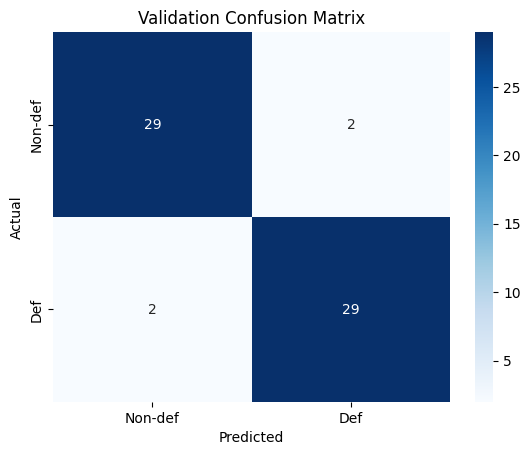

Classification Report - Validation:


,Class,Precision,Recall,F1-score,Accuracy
0,Non defective,0.935484,0.935484,0.935484,0.935484
1,Defective,0.935484,0.935484,0.935484,0.935484
2,Macro avg,0.935484,0.935484,0.935484,0.935484
3,Weighted avg,0.935484,0.935484,0.935484,0.935484


In [41]:

# Validation metrics
val_pred = best.predict(X_val_feat)
val_table = create_metrics_table(y_val, val_pred)

plot_cm(y_val, val_pred, "Validation Confusion Matrix")

print('Classification Report - Validation:')
display(val_table)

In [ ]:
# Debug: Kiểm tra chi tiết metrics từng class
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_val, val_pred)
acc = accuracy_score(y_val, val_pred)

print('=== DEBUG: Chi tiết tính toán Validation ===')
print(f'\nDữ liệu:')
print(f'  Tổng mẫu: {len(y_val)}')
print(f'  Class 0 (Non-def): {support[0]} mẫu')
print(f'  Class 1 (Defective): {support[1]} mẫu')

print(f'\nMetrics từ sklearn.metrics.precision_recall_fscore_support:')
print(f'  Class 0 - Precision: {precision[0]:.6f}, Recall: {recall[0]:.6f}, F1: {f1[0]:.6f}')
print(f'  Class 1 - Precision: {precision[1]:.6f}, Recall: {recall[1]:.6f}, F1: {f1[1]:.6f}')

print(f'\nMacro Average (trung bình số học):')
print(f'  Precision: {precision.mean():.6f}')
print(f'  Recall: {recall.mean():.6f}')
print(f'  F1-score: {f1.mean():.6f}')

print(f'\nWeighted Average (trung bình có trọng số):')
print(f'  Precision: {(precision*support).sum()/support.sum():.6f}')
print(f'  Recall: {(recall*support).sum()/support.sum():.6f}')
print(f'  F1-score: {(f1*support).sum()/support.sum():.6f}')

print(f'\nAccuracy (từ sklearn): {acc:.6f}')

print(f'\n→ Nếu dataset cân bằng (50-50) và model dự đoán đối xứng,')
print(f'  TẤT CẢ metrics sẽ BẰNG NHAU - đây là ĐÚNG, không phải sai!')

# Phase 3 — Final Test Evaluation

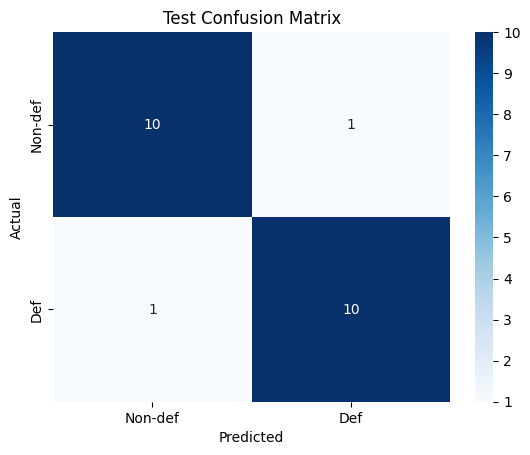

Classification Report - Test:


,Class,Precision,Recall,F1-score,Accuracy
0,Non defective,0.909091,0.909091,0.909091,0.909091
1,Defective,0.909091,0.909091,0.909091,0.909091
2,Macro avg,0.909091,0.909091,0.909091,0.909091
3,Weighted avg,0.909091,0.909091,0.909091,0.909091


In [42]:

# Test metrics
test_pred = best.predict(X_test_feat)
test_table = create_metrics_table(y_test, test_pred)

plot_cm(y_test, test_pred, "Test Confusion Matrix")

print('Classification Report - Test:')
display(test_table)


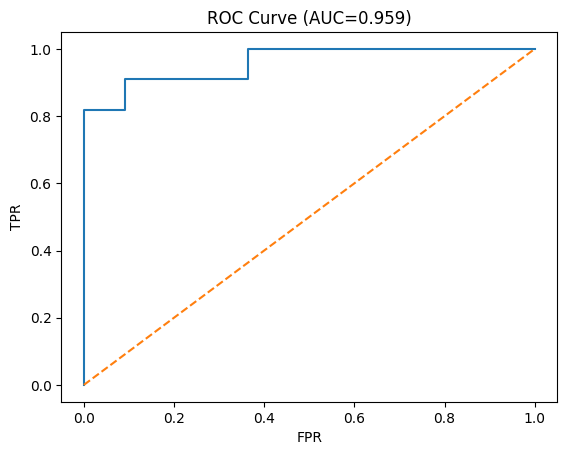

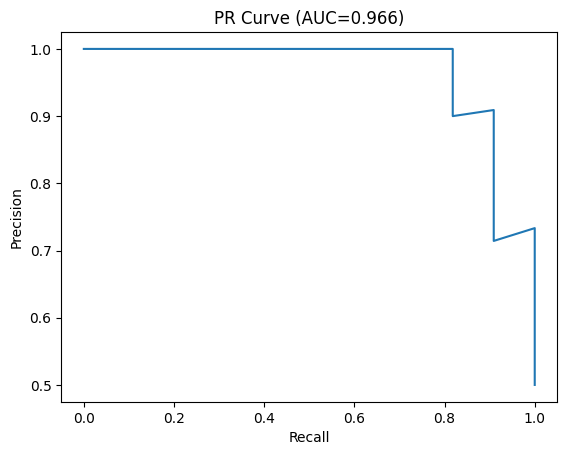

(0.9586776859504131, 0.9662140889413617)

[CV] END ...svc__C=0.1, svc__gamma=0.001, svc__kernel=linear; total time=  12.6s
[CV] END ......svc__C=0.1, svc__gamma=0.001, svc__kernel=rbf; total time=  41.5s
[CV] END ......svc__C=0.1, svc__gamma=0.005, svc__kernel=rbf; total time=  41.6s
[CV] END ...svc__C=0.5, svc__gamma=0.001, svc__kernel=linear; total time=  10.8s
[CV] END ...svc__C=0.5, svc__gamma=0.001, svc__kernel=linear; total time=  11.8s
[CV] END ...svc__C=0.5, svc__gamma=0.001, svc__kernel=linear; total time=  11.6s
[CV] END ......svc__C=0.5, svc__gamma=0.001, svc__kernel=rbf; total time=  38.5s
[CV] END ......svc__C=0.5, svc__gamma=0.005, svc__kernel=rbf; total time=  43.7s
[CV] END .....svc__C=1, svc__gamma=0.001, svc__kernel=linear; total time=  10.6s
[CV] END .....svc__C=1, svc__gamma=0.001, svc__kernel=linear; total time=  11.4s
[CV] END .....svc__C=1, svc__gamma=0.001, svc__kernel=linear; total time=  12.4s
[CV] END .....svc__C=1, svc__gamma=0.005, svc__kernel=linear; total time=  11.1s
[CV] END .....svc__C=1, svc_

In [18]:

# ROC and PR curves
y_proba = best.predict_proba(X_test_feat)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve (AUC={:.3f})".format(roc_auc))
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.show()

# PR
scores = best.decision_function(X_test_feat)
prec, rec, _ = precision_recall_curve(y_test, scores)
pr_auc = auc(rec, prec)

plt.plot(rec, prec)
plt.title("PR Curve (AUC={:.3f})".format(pr_auc))
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.show()

roc_auc, pr_auc
